# Pair Distribution Function Analysis of Amorphous Materials

Karen Ehrhardt | Mar 17 2026

## Introduction

The **pair distribution function (PDF)** describes the probability of finding pairs of atoms separated by a given distance in a material. This tool is especially useful for characterizing the local atomic structure of amorphous and disordered materials, where traditional crystallographic techniques based on Bragg diffraction are not applicable.

In this tutorial, we will:
1. Load a simulated 4D-STEM dataset of amorphous tantalum (Ta)
2. Apply a polar transform to the diffraction patterns
3. Calculate the PDF from the diffuse scattering signal
4. Compare our result to a ground truth PDF calculated directly from atomic coordinates

### Data source

The amorphous Ta coordinates were created by Jun Ding and Mark Asta ([reference](https://www.pnas.org/doi/full/10.1073/pnas.1705723114)). The simulated 4D-STEM dataset was prepared by Stephanie Ribet (sribet@lbl.gov.)

The tutorial will automatically download the following data files:
- Simulated 4D-STEM scan of amorphous Ta (`Ta_sim_binned.zip`)
- Ground truth RDF calculated from atomic coordinates (`Ta_sim_rdf.npz`)

**Note:** Update the download URLs in the code cell below to point to your hosted data files.

## Load data

First, we load our 4D-STEM dataset. This simulated dataset contains a 20x20 grid of probe positions, with a 307x307 pixel diffraction pattern at each position. This can be confirmed by looking at ds.shape, which contains (xprobe, yprobe, kx, ky).

In [1]:
%load_ext autoreload
%autoreload 2


In [2]:
import quantem as em
from quantem.core.io.serialize import load
from quantem.core.datastructures import Dataset4dstem
from quantem.diffraction.polar_transform import auto_origin_id, polar_transform
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Links to data
url_4dstem = "https://drive.google.com/file/d/1w7bO1ex0aN6okp-XdKWs_6ECU8kScPUA/view"
url_rdf = "https://drive.google.com/file/d/1ELkurL7jGlaCvGZJCGOhDpMbHj1aX_zz/view"  # Update this URL

# Set paths to downloaded file locations
file_path = Path("/path/to/Ta_sim_binned.zip")
file_rdf = Path("/path/to/Ta_sim_rdf.npz")

In [4]:
# Load 4D-STEM data P
ds = load(file_path)
print(type(ds))
print(getattr(ds, "array", None).shape if hasattr(ds, "array") else "No .array attribute found")


<class 'quantem.core.datastructures.dataset4dstem.Dataset4dstem'>
(20, 20, 307, 307)


## Polar transform

Before calculating the PDF, we need to convert our diffraction patterns from Cartesian (x, y) coordinates to polar (phi, radius) coordinates. This will enable us to later calculate the radially-averaged intensity profiles for the PDF.

The polar transform requires knowing the center (origin) of each diffraction pattern. You can either:
- **Specify the origin manually** using `origin_array`
- **Use automatic origin finding** (default), which minimizes the intensity variation along the angular direction.

The latter option (default) is recommended for experimental datasets or any dataset where the origin position may vary between scan pixels. An incorrect center will introduce significant artifacts into the PDF.

### Manual origin selection (not recommended)

Here we deliberately choose a poor origin (150, 150) to demonstrate what happens when the center is incorrect. In the polar transform visualization below, notice the "wavy" intensity variations along the angular (phi) direction. This indicates the origin is off-center.

In [5]:
polar = polar_transform(
    ds,
    origin_array=[150, 150],
)
#manually setting known q-sampling
polar.sampling[3] = 0.01488
polar

Dataset(shape=(20, 20, 180, 150), dtype=float32, name='4D-STEM dataset_polar')
  sampling: [1.      1.      2.      0.01488]
  units: ['pixels', 'pixels', 'deg', 'pixels']
  signal units: 'arb. units'

(<Figure size 1200x300 with 4 Axes>,
 array([<Axes: title={'center': 'image'}>,
        <Axes: title={'center': 'polar transform'}>,
        <Axes: title={'center': 'polar transform * k'}>,
        <Axes: title={'center': 'polar transform * k**2'}>], dtype=object))

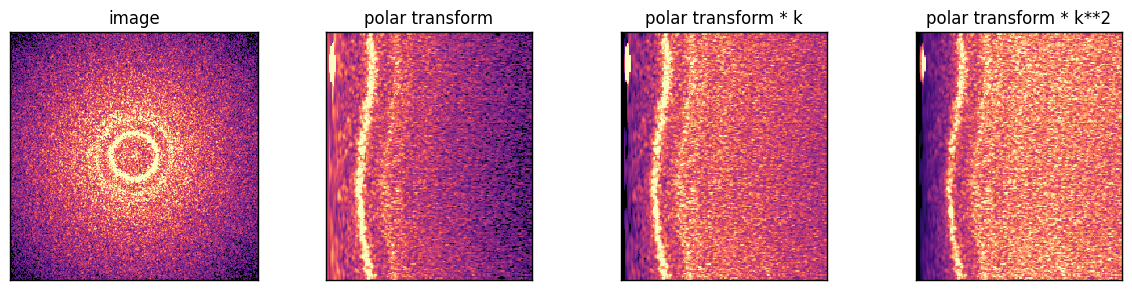

In [6]:
xind,yind = 10,10

# radial bin centers in pixels
r_bins = np.arange(polar.shape[3], dtype=float)

em.visualization.show_2d(
    [
        ds.array[xind,yind],
        polar.array[xind,yind],
        polar.array[xind,yind] * r_bins[None,:],
        polar.array[xind,yind] * r_bins[None,:]**2,
    ],
    vmin = 0,
    norm = {
        'power': 0.25,
    },
    title = [
        'image',
        'polar transform',
        'polar transform * k',
        'polar transform * k**2',
    ],
    cmap='magma',
    axsize = (3,3),
)

### Automatic origin selection (recommended)

Now we use `ds.auto_origin_id()`, which finds the optimal center for each scan position by minimizing the standard deviation of intensity along the angular direction. The routine warm-starts each position from the previous result, so it scales efficiently over large scans.

After origin finding, we pass the origin array to `polar_transform`. Notice how the intensity is now uniform along the angular direction, indicating a well-centered polar transform. The per-position origins are stored on the `Polar4dstem` object as `polar.origin_array`.

Finding origin for each scan position: 100%|██████████| 400/400 [00:04<00:00, 96.49it/s]


Origins shape: (20, 20, 2)
Origin at (10,10): row=153.0, col=153.0

Polar shape: (20, 20, 180, 151)
origin_array stored: True


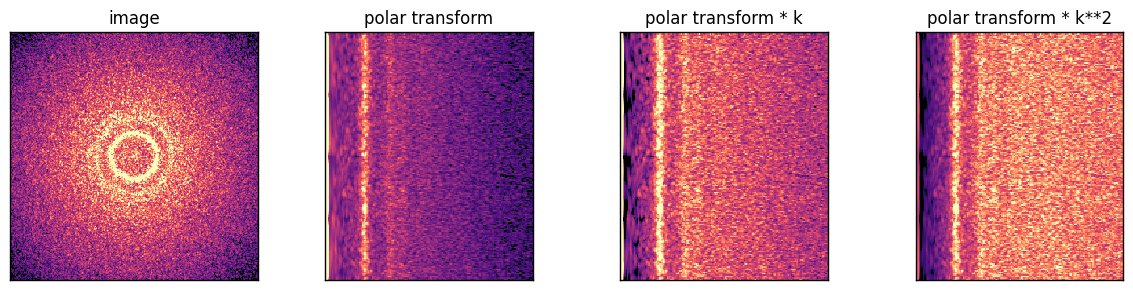

In [7]:
# Find optimal diffraction center for each scan position
origins = auto_origin_id(ds)
print(f"Origins shape: {origins.shape}")
print(f"Origin at (10,10): row={origins[10,10,0]:.1f}, col={origins[10,10,1]:.1f}")
# Apply polar transform with optimized origins
polar = polar_transform(ds, origin_array=origins)
polar.sampling[3] = 0.01488
# The per-position origins are stored on the Polar4dstem object
print(f"\nPolar shape: {polar.shape}")
print(f"origin_array stored: {polar.origin_array is not None}")

xind, yind = 10, 10
# radial bin centers in pixels
r_bins = np.arange(polar.shape[3], dtype=float)
em.visualization.show_2d(
    [
        ds.array[xind, yind],
        polar.array[xind, yind],
        polar.array[xind, yind] * r_bins[None, :],
        polar.array[xind, yind] * r_bins[None, :] ** 2,
    ],
    vmin=0,
    norm={
        'power': 0.25,
    },
    title=[
        'image',
        'polar transform',
        'polar transform * k',
        'polar transform * k**2',
    ],
    cmap='magma',
    axsize=(3, 3),
);

## Calculate pair distribution function

Now we calculate the PDF from our 4D-STEM dataset. `PairDistributionFunction.from_data` handles origin finding and the polar transform internally when given a `Dataset4dstem` object, so there is no need to run them separately.

The PDF workflow involves two main steps:

### Step 1: `calculate_Gr` — Reduced PDF G(r)
1. **Radial averaging** — Azimuthal average of the polar-transformed intensity to get I(k)
2. **Background subtraction** — Fit and remove the background scattering contribution  
    &nbsp;&nbsp;&nbsp;&nbsp;Background model: $B(k) = c + i_0 \exp\!\left(-\frac{k^2}{2 s_0^2}\right) + i_1 \exp\!\left(-\frac{k^4}{2 s_1^4}\right)$
3. **Structure factor** — Convert the corrected intensity to the reduced structure factor F(k)
4. **Fourier transform** — Windowed sine transform of F(k) to obtain the reduced PDF G(r)

### Step 2 (optional): `calculate_gr` — Pair distribution function g(r)
5. **Density estimation** — Estimate the atomic number density ρ₀ (or provide a known value)
6. **Convert G(r) → g(r)** — Apply the relation $g(r) = 1 + G(r) / (4\pi r \rho_0)$

In [8]:
# Create PDF object directly from the 4D-STEM dataset
# find_origin=True runs auto_origin_id internally
rdf = em.diffraction.PairDistributionFunction.from_data(polar)

rdf.calculate_Gr(
    r_max=20.0,
    k_min_fit=0.05,
    
)

### Visualize intermediate results

We can inspect the stages of the calculation with `plot_pdf_results`. Available plot names:
- `radial_mean` — The radially averaged diffraction intensity I(k)
- `background_fits` — The fitted background model overlaid on I(k)
- `reduced_sf` — The reduced structure factor F(k) with window applied
- `reduced_pdf` — The reduced pair distribution function G(r)
- `pdf` — The pair distribution function g(r) (requires `calculate_gr` first)
- `oscillation_damping` — Before/after comparison of origin oscillation damping

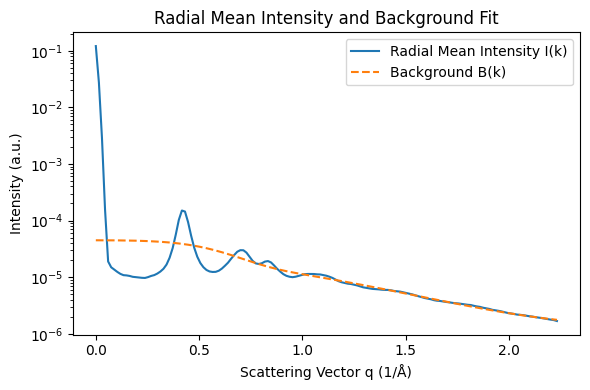

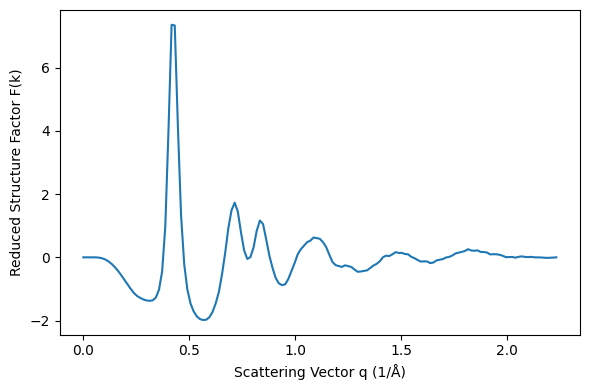

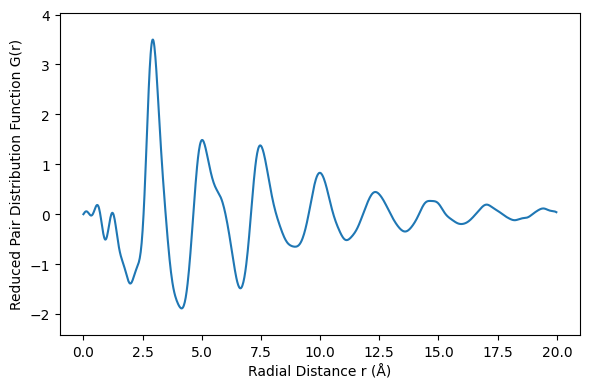

In [9]:
rdf.plot_pdf_results(
    [
        "background_fits", 
        "reduced_sf", 
        "reduced_pdf"
    ],
)

### Manual step-by-step pathway

The steps above used `calculate_Gr`, which internally calls `calculate_radial_mean` and `fit_bg`. You can also call each step individually to inspect or customize intermediate results:

In [10]:
rdf = em.diffraction.PairDistributionFunction.from_data(polar)
# Azimuthal average to get I(k)
Ik = rdf.calculate_radial_mean(returnval=True)
# Fit background B(k) to I(k) — stores bg and f on rdf for reuse
bg, f = rdf.fit_bg(Ik, kmin=0.05)
# calculate_Gr reuses the stored background fit from fit_bg above
r, Gr = rdf.calculate_Gr(k_min_fit=0.05, r_max=20.0, returnval=True)

## Refining the PDF: density estimation and oscillation damping

The raw PDF often shows spurious oscillations near r = 0, which are unphysical (because atoms cannot physically be that close). These artifacts arise from truncation effects in the Fourier transform.

The `damp_origin_oscillations` option addresses this by iteratively fitting the structure factor S(k) to estimate the atomic density. This produces:
- A density estimate ρ₀
- A corrected S(k) that is more physically consistent
- A cleaner G(r) with reduced oscillations at low r

After computing the refined G(r), `calculate_gr` converts it to the pair distribution function g(r) using the estimated density (stored in `rdf.rho0`). A user-provided density can also be passed directly.

Reference: [Yoshimoto and Omote, 2022](https://journals.jps.jp/doi/10.7566/JPSJ.91.104602)

In [11]:
# Recalculate G(r) with origin oscillation damping
rdf.calculate_Gr(
    r_max=20.0,
    k_min_fit=0.05,
    # k_max=0.8,
    # k_lowpass=0.02,
    damp_origin_oscillations=True,
)

# Calculate g(r) using the density estimated during damping
r, gr = rdf.calculate_gr(
    set_pdf_positive=True,
    returnval=True,
)

  Using estimated rho0 = 0.035273 atoms/A^3


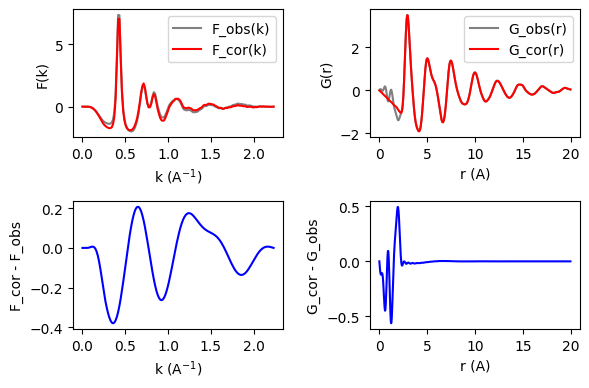

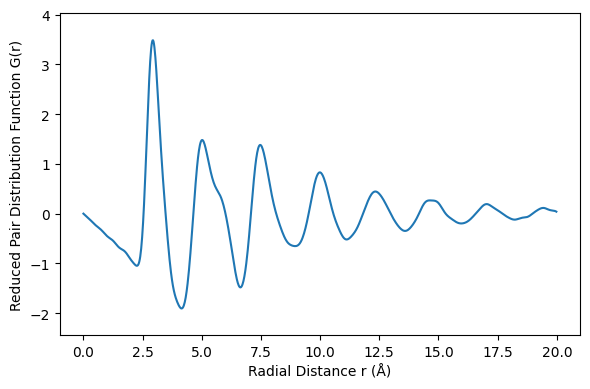

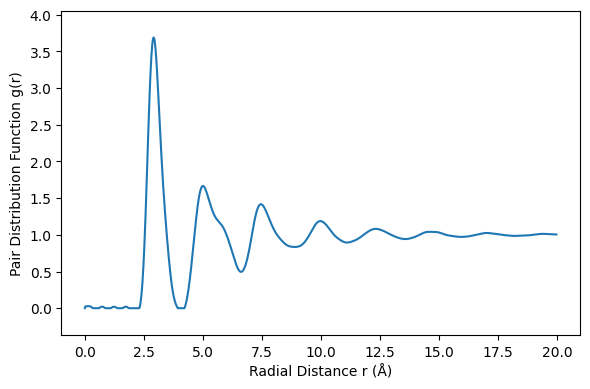

In [12]:
rdf.plot_pdf_results(
    [
        "oscillation_damping",
        "reduced_pdf",
        "pdf",
    ],
)

## Validate against ground truth

Since we are working with simulated data, we can compare our calculated PDF to a pre-calculated "ground truth" PDF computed directly from the atomic coordinates to assess the accuracy of the PDF workflow.

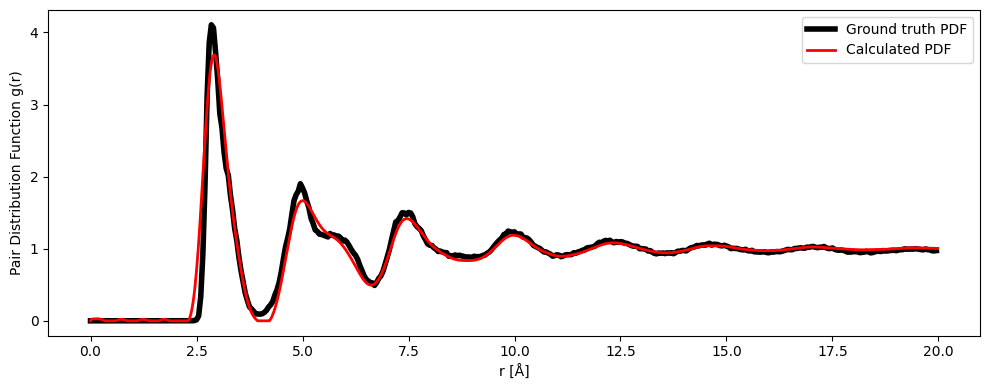

In [13]:
# Load ground truth RDF from atomic coordinates
rdf_truth = np.load(file_rdf)

# Compare to calculated PDF
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    rdf_truth['r'],
    rdf_truth['gr'],
    color='k',
    linewidth=4,
    label="Ground truth PDF"
)

ax.plot(
    rdf.r,
    rdf.pdf,
    color='r',
    linewidth=2,
    label="Calculated PDF"
)

ax.set_xlabel("r [Å]")
ax.set_ylabel("Pair Distribution Function g(r)")
plt.legend()
plt.tight_layout()
plt.show()